# Partie 17 — Représentation vectorielle avec TF-IDF

Les modèles de machine learning ne comprennent pas directement les textes.

Il est donc nécessaire de transformer les titres des publications en représentations numériques.

Pour cela, nous utilisons TF-IDF (Term Frequency – Inverse Document Frequency).

Cette méthode attribue un poids important :
- aux mots fréquents dans un document ;
- mais rares dans l’ensemble du corpus.

Ainsi, les mots discriminants comme "penalty" ou "VAR" obtiennent généralement un poids plus élevé que des mots très fréquents comme "match".

In [1]:
import json
import re
import csv
import pandas as pd
from datetime import datetime

In [2]:
import pandas as pd

df_resultats = pd.read_csv("resultats_tal_galata_liverpool.csv")

df_resultats.head()

,heure,titre,evenement,score,commentaires,commentaires_periode,minute_match,categorie_temps
0,2026-03-19 10:09:51 UTC,Looking at the sequence of events around Liver...,AUTRE,NaN,9,0,12369,APRES_MATCH
1,2026-02-02 12:48:25 UTC,"10 years ago today, Jamie Vardy’s volley vs Li...",VAR,NaN,338,0,-52272,AVANT_MATCH
2,2026-05-03 13:27:26 UTC,Match Thread: Manchester United vs Liverpool |...,MATCH_THREAD,14:30,484,0,77367,APRES_MATCH
3,2025-09-30 21:02:05 UTC,Post Match Thread: Galatasaray 1 : Liverpool 0...,FIN_MATCH,NaN,466,0,-231778,AVANT_MATCH
4,2023-03-05 18:20:47 UTC,Post Match Thread: Liverpool 7 - 0 Manchester ...,FIN_MATCH,7 - 0,376,0,-1585540,AVANT_MATCH


In [12]:
print(df_resultats.columns)

RangeIndex(start=0, stop=0, step=1)


In [4]:
import pandas as pd
import os

for fichier in ["resultats_tal.csv", "resultats_tal_galata_liverpool.csv"]:
    print("\nFichier :", fichier)
    print("Taille :", os.path.getsize(fichier), "octets")
    
    try:
        df_test = pd.read_csv(fichier)
        print("Shape :", df_test.shape)
        print("Colonnes :", df_test.columns.tolist())
        display(df_test.head())
    except Exception as e:
        print("Erreur :", e)


Fichier : resultats_tal.csv
Taille : 23211 octets
Shape : (200, 4)
Colonnes : ['heure', 'evenement', 'score', 'titre']


,heure,evenement,score,titre
0,2025-08-29 15:19:49 UTC,MATCH_THREAD,NaN,[Pre-match Thread] Tottenham Hotspur vs AFC Bo...
1,2026-03-19 10:09:51 UTC,AUTRE,NaN,Looking at the sequence of events around Liver...
2,2020-12-01 14:40:08 UTC,AUTRE,NaN,Each national team's youngest player: Where ar...
3,2023-12-05 13:35:28 UTC,BUT,NaN,[Press Conference] Erik ten Hag on if media st...
4,2026-02-02 12:48:25 UTC,VAR,NaN,"10 years ago today, Jamie Vardy’s volley vs Li..."



Fichier : resultats_tal_galata_liverpool.csv
Taille : 12706 octets
Shape : (90, 8)
Colonnes : ['heure', 'titre', 'evenement', 'score', 'commentaires', 'commentaires_periode', 'minute_match', 'categorie_temps']


,heure,titre,evenement,score,commentaires,commentaires_periode,minute_match,categorie_temps
0,2026-03-19 10:09:51 UTC,Looking at the sequence of events around Liver...,AUTRE,NaN,9,0,12369,APRES_MATCH
1,2026-02-02 12:48:25 UTC,"10 years ago today, Jamie Vardy’s volley vs Li...",VAR,NaN,338,0,-52272,AVANT_MATCH
2,2026-05-03 13:27:26 UTC,Match Thread: Manchester United vs Liverpool |...,MATCH_THREAD,14:30,484,0,77367,APRES_MATCH
3,2025-09-30 21:02:05 UTC,Post Match Thread: Galatasaray 1 : Liverpool 0...,FIN_MATCH,NaN,466,0,-231778,AVANT_MATCH
4,2023-03-05 18:20:47 UTC,Post Match Thread: Liverpool 7 - 0 Manchester ...,FIN_MATCH,7 - 0,376,0,-1585540,AVANT_MATCH


In [5]:
titres = df_resultats["titre"]

print("Nombre de titres :", len(titres))

print("\nPremier titre :")
print(titres.iloc[0])

Nombre de titres : 90

Premier titre :
Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?


# Partie 17 — Vectorisation TF-IDF

Nous allons maintenant transformer les titres en vecteurs numériques.

Un modèle de machine learning ne comprend pas directement les phrases.  
TF-IDF permet de représenter chaque titre par une liste de nombres indiquant l’importance des mots.

Cette étape marque le passage d’une approche symbolique par règles à une approche statistique.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(titres)

print("Dimensions de la matrice TF-IDF :", X.shape)

Dimensions de la matrice TF-IDF : (90, 346)


In [7]:
mots = vectorizer.get_feature_names_out()

print("Nombre de mots appris :", len(mots))
print(mots[:50])

Nombre de mots appris : 346
['00' '03' '10' '13' '14' '16' '17' '18' '1976' '1999' '20' '2000' '2024'
 '2025' '2026' '24' '25' '250' '26' '2nd' '30' '35' '433' '45' 'about'
 'across' 'afc' 'after' 'again' 'against' 'agg' 'aggregate' 'ago' 'also'
 'amazing' 'and' 'anfield' 'appeal' 'arne' 'around' 'arsenal' 'arteta'
 'as' 'asking' 'aston' 'at' 'atalanta' 'atleti' 'atletico' 'available']


In [8]:
premier_vecteur = X[0]

print(premier_vecteur)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (1, 346)>
  Coords	Values
  (0, 187)	0.28874270759680043
  (0, 45)	0.24719992128312934
  (0, 296)	0.3627123256009773
  (0, 278)	0.28874270759680043
  (0, 222)	0.17655891743311491
  (0, 113)	0.28874270759680043
  (0, 39)	0.28874270759680043
  (0, 185)	0.0661750695045713
  (0, 327)	0.102138614263575
  (0, 136)	0.1048633367244775
  (0, 94)	0.28874270759680043
  (0, 79)	0.28874270759680043
  (0, 123)	0.28874270759680043
  (0, 134)	0.28874270759680043
  (0, 51)	0.28874270759680043


In [9]:
vecteur_dense = X[0].toarray()[0]

for i in range(len(mots)):
    if vecteur_dense[i] > 0:
        print(mots[i], ":", round(vecteur_dense[i], 3))

around : 0.289
at : 0.247
balanced : 0.289
conditions : 0.289
did : 0.289
events : 0.289
feel : 0.289
fully : 0.289
galatasaray : 0.105
liverpool : 0.066
looking : 0.289
of : 0.177
sequence : 0.289
the : 0.363
vs : 0.102


# Partie 19 — Création des labels

Après la vectorisation TF-IDF, nous devons définir la variable cible du modèle.

La variable cible correspond à l’événement associé à chaque titre :
- FIN_MATCH
- MATCH_THREAD
- VAR
- PENALTY
- BUT
- AUTRE

Dans cette première expérimentation, nous utilisons les événements obtenus par l’approche par règles comme labels.

In [10]:
y = df_resultats["evenement"]

print("Nombre de labels :", len(y))
print("\nExemples de labels :")
print(y.head(10))

Nombre de labels : 90

Exemples de labels :
0           AUTRE
1             VAR
2    MATCH_THREAD
3       FIN_MATCH
4       FIN_MATCH
5       FIN_MATCH
6    MATCH_THREAD
7           AUTRE
8       FIN_MATCH
9             BUT
Name: evenement, dtype: object


# Partie 20 — Séparation apprentissage / test

Avant d’entraîner un modèle de classification, nous séparons les données en deux ensembles :
- un ensemble d’apprentissage, utilisé pour entraîner le modèle ;
- un ensemble de test, utilisé pour évaluer sa capacité à prédire de nouveaux exemples.

Cette séparation permet de vérifier si le modèle généralise réellement ou s’il se contente de mémoriser les données.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Taille apprentissage :", X_train.shape)
print("Taille test :", X_test.shape)

Taille apprentissage : (72, 346)
Taille test : (18, 346)


# Partie 21 — Entraînement d’un modèle de classification

Après la vectorisation TF-IDF et la séparation apprentissage/test, nous entraînons un modèle de classification.

Nous utilisons ici une régression logistique, qui est un modèle classique en traitement automatique du langage.

L’objectif est d’apprendre automatiquement à associer un titre à une catégorie d’événement.

In [12]:
from sklearn.linear_model import LogisticRegression

modele = LogisticRegression(max_iter=1000)

modele.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Partie 22 — Prédiction sur l’ensemble de test

Après l’entraînement, nous utilisons le modèle pour prédire les événements associés aux titres de l’ensemble de test.

L’objectif est de comparer :
- les vraies classes ;
- les classes prédites par le modèle.

Cela permet d’observer les premières performances du classifieur.

In [13]:
y_pred = modele.predict(X_test)

print("Prédictions réalisées.")

Prédictions réalisées.


In [14]:
comparaison = pd.DataFrame({
    "vrai_evenement": y_test.values,
    "evenement_predit": y_pred
})

comparaison.head(20)

,vrai_evenement,evenement_predit
0,MATCH_THREAD,MATCH_THREAD
1,MATCH_THREAD,MATCH_THREAD
2,MATCH_THREAD,MATCH_THREAD
3,AUTRE,AUTRE
4,AUTRE,AUTRE
5,FIN_MATCH,FIN_MATCH
6,FIN_MATCH,FIN_MATCH
7,AUTRE,AUTRE
8,FIN_MATCH,FIN_MATCH
9,MATCH_THREAD,MATCH_THREAD


# Partie 23 — Évaluation du modèle

Après les prédictions, nous évaluons les performances du modèle.

Nous utilisons plusieurs mesures :
- l’accuracy, qui indique le pourcentage de prédictions correctes ;
- le rapport de classification, qui détaille les performances pour chaque classe.

Cette étape permet de mesurer la qualité du classifieur et d’identifier ses limites.

In [15]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 3))

Accuracy : 0.889


# Partie 24 — Analyse des erreurs de classification

Après l’évaluation globale du modèle, nous analysons les erreurs de prédiction.

Cette étape est importante car elle permet de comprendre :
- quelles classes sont confondues ;
- quels types de titres sont mal classés ;
- quelles limites apparaissent dans le modèle.

L’analyse des erreurs permet aussi de proposer des améliorations futures.

In [16]:
comparaison["correct"] = comparaison["vrai_evenement"] == comparaison["evenement_predit"]

comparaison.head()

,vrai_evenement,evenement_predit,correct
0,MATCH_THREAD,MATCH_THREAD,True
1,MATCH_THREAD,MATCH_THREAD,True
2,MATCH_THREAD,MATCH_THREAD,True
3,AUTRE,AUTRE,True
4,AUTRE,AUTRE,True


In [17]:
erreurs = comparaison[comparaison["correct"] == False]

erreurs

,vrai_evenement,evenement_predit,correct
10,AUTRE,MATCH_THREAD,False
11,BUT,AUTRE,False


In [18]:
print("Nombre d'erreurs :", len(erreurs))
print("Nombre total de tests :", len(comparaison))

Nombre d'erreurs : 2
Nombre total de tests : 18


# Partie 25 — Matrice de confusion

La matrice de confusion permet d'observer précisément les erreurs du modèle.

Chaque ligne représente la vraie classe.

Chaque colonne représente la classe prédite.

Une bonne matrice présente des valeurs importantes sur la diagonale principale, ce qui signifie que les prédictions correspondent aux vraies classes.

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4 0 0 1]
 [1 0 0 0]
 [0 0 5 0]
 [0 0 0 7]]


In [20]:
import pandas as pd

classes = sorted(y.unique())

df_cm = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

df_cm

ValueError: Shape of passed values is (4, 4), indices imply (6, 6)

# Partie 26 — Interprétation du modèle

L’un des avantages de la régression logistique est son interprétabilité.

Chaque mot du vocabulaire reçoit un poids pour chaque classe.

Les mots ayant les poids les plus élevés sont ceux qui influencent le plus les prédictions du modèle.

Cette analyse permet de comprendre quelles informations textuelles sont utilisées pour détecter les événements.

In [21]:
classes = modele.classes_

print(classes)

['AUTRE' 'BUT' 'CARTON_ROUGE' 'FIN_MATCH' 'MATCH_THREAD' 'VAR']


In [22]:
for i, classe in enumerate(classes):

    print("\n", "=" * 50)
    print("Classe :", classe)

    indices = modele.coef_[i].argsort()[-10:]

    for idx in reversed(indices):
        print(
            mots[idx],
            "->",
            round(modele.coef_[i][idx], 3)
        )


Classe : AUTRE
matchday -> 0.552
galatasaray -> 0.498
the -> 0.416
last -> 0.388
draws -> 0.338
draw -> 0.321
from -> 0.278
their -> 0.274
in -> 0.273
before -> 0.265

Classe : BUT
asking -> 0.388
they -> 0.36
if -> 0.298
frimpong -> 0.263
that -> 0.241
has -> 0.225
goalkeeper -> 0.194
remember -> 0.194
randomly -> 0.194
reporter -> 0.194

Classe : CARTON_ROUGE
not -> 0.428
be -> 0.258
red -> 0.255
will -> 0.219
about -> 0.143
card -> 0.143
straight -> 0.143
talking -> 0.143
available -> 0.143
saliba -> 0.143

Classe : FIN_MATCH
post -> 2.233
match -> 0.721
uefa -> 0.711
manchester -> 0.652
thread -> 0.645
md2 -> 0.564
united -> 0.486
day -> 0.435
league -> 0.422
real -> 0.403

Classe : MATCH_THREAD
vs -> 1.531
thread -> 1.183
match -> 0.956
fc -> 0.61
pre -> 0.57
pl -> 0.5
utc -> 0.435
26 -> 0.41
liverpool -> 0.397
tottenham -> 0.365

Classe : VAR
wolves -> 0.358
equalizer -> 0.358
rules -> 0.358
neto -> 0.358
out -> 0.358
var -> 0.358
volley -> 0.341
vardy -> 0.341
jamie -> 0.341
ag

# Partie 27 — Amélioration des règles de détection

L’analyse des mots appris par le modèle a révélé certaines erreurs dans les labels automatiques.

Par exemple, la règle initiale détectait la chaîne "var" même à l’intérieur du mot "Vardy".  
Cela provoquait une mauvaise annotation de certains titres.

Nous améliorons donc les règles en utilisant des expressions régulières avec des frontières de mots, afin de détecter uniquement les mots complets.

In [23]:
def detecter_evenement_v2(titre):
    texte = nettoyer_texte(titre)

    if re.search(r"\bpost\s+match\b", texte):
        return "FIN_MATCH"

    elif re.search(r"\bmatch\s+thread\b", texte):
        return "MATCH_THREAD"

    elif re.search(r"\bvar\b", texte):
        return "VAR"

    elif re.search(r"\bpenalty\b|\bpens\b", texte):
        return "PENALTY"

    elif re.search(r"\bgoal\b|\bbut\b", texte):
        return "BUT"

    elif re.search(r"\bred\s+card\b|\bcarton\s+rouge\b", texte):
        return "CARTON_ROUGE"

    else:
        return "AUTRE"

In [25]:
import re

def nettoyer_texte(texte):
    texte = texte.lower()
    texte = re.sub(r"[^\w\s\-:]", "", texte)
    texte = re.sub(r"(.)\1{2,}", r"\1", texte)
    return texte

In [26]:
df_resultats["evenement_v2"] = df_resultats["titre"].apply(detecter_evenement_v2)

df_resultats[["titre", "evenement", "evenement_v2"]].head(20)

,titre,evenement,evenement_v2
0,Looking at the sequence of events around Liver...,AUTRE,AUTRE
1,"10 years ago today, Jamie Vardy’s volley vs Li...",VAR,AUTRE
2,Match Thread: Manchester United vs Liverpool |...,MATCH_THREAD,MATCH_THREAD
3,Post Match Thread: Galatasaray 1 : Liverpool 0...,FIN_MATCH,FIN_MATCH
4,Post Match Thread: Liverpool 7 - 0 Manchester ...,FIN_MATCH,FIN_MATCH
5,Post Match Thread: Manchester United 3-2 Liver...,FIN_MATCH,FIN_MATCH
6,[Match Thread] Liverpool FC vs Crystal Palace,MATCH_THREAD,MATCH_THREAD
7,Anfield roof leaking during last night's Liver...,AUTRE,AUTRE
8,Post Match Thread: Galatasaray 1-0 Liverpool,FIN_MATCH,FIN_MATCH
9,BBC reporter randomly asking if they remember ...,BUT,AUTRE


In [27]:
pd.crosstab(df_resultats["evenement"], df_resultats["evenement_v2"])

evenement_v2,AUTRE,BUT,CARTON_ROUGE,FIN_MATCH,MATCH_THREAD,VAR
evenement,,,,,,
AUTRE,28,0,0,0,0,0
BUT,2,1,0,0,0,0
CARTON_ROUGE,0,0,1,0,0,0
FIN_MATCH,0,0,0,19,2,0
MATCH_THREAD,0,0,0,0,35,0
VAR,1,0,0,0,0,1


# Partie 28 — Comparaison entre les anciens labels et les labels améliorés

Après avoir amélioré les règles de détection, nous comparons les anciens labels avec les nouveaux labels.

Cette comparaison permet d’identifier les catégories qui ont changé et de vérifier si les erreurs observées précédemment ont été corrigées.

In [28]:
pd.crosstab(
    df_resultats["evenement"],
    df_resultats["evenement_v2"]
)

evenement_v2,AUTRE,BUT,CARTON_ROUGE,FIN_MATCH,MATCH_THREAD,VAR
evenement,,,,,,
AUTRE,28,0,0,0,0,0
BUT,2,1,0,0,0,0
CARTON_ROUGE,0,0,1,0,0,0
FIN_MATCH,0,0,0,19,2,0
MATCH_THREAD,0,0,0,0,35,0
VAR,1,0,0,0,0,1


In [29]:
changements = df_resultats[
    df_resultats["evenement"] != df_resultats["evenement_v2"]
]

changements[["titre", "evenement", "evenement_v2"]]

,titre,evenement,evenement_v2
1,"10 years ago today, Jamie Vardy’s volley vs Li...",VAR,AUTRE
9,BBC reporter randomly asking if they remember ...,BUT,AUTRE
12,Post-Match Thread: Watford 3 - 0 Liverpool [ E...,FIN_MATCH,MATCH_THREAD
23,Post-Match Thread: Galatasaray vs. Juventus | ...,FIN_MATCH,MATCH_THREAD
35,[MisterChip] Only one team in history has ever...,BUT,AUTRE


# Partie 29 — Réentraînement avec les labels améliorés

Après avoir corrigé certaines erreurs dans les règles de détection, nous réentraînons le modèle avec les nouveaux labels `evenement_v2`.

L’objectif est de vérifier si l’amélioration des annotations permet d’obtenir un modèle plus cohérent.

In [30]:
y_v2 = df_resultats["evenement_v2"]

print("Nombre de labels v2 :", len(y_v2))
print(y_v2.value_counts())

Nombre de labels v2 : 90
evenement_v2
MATCH_THREAD    37
AUTRE           31
FIN_MATCH       19
VAR              1
CARTON_ROUGE     1
BUT              1
Name: count, dtype: int64


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_v2,
    test_size=0.2,
    random_state=42
)

print("Taille apprentissage :", X_train.shape)
print("Taille test :", X_test.shape)

Taille apprentissage : (72, 346)
Taille test : (18, 346)


In [32]:
modele_v2 = LogisticRegression(max_iter=1000)

modele_v2.fit(X_train, y_train)

print("Modèle v2 entraîné avec succès.")

Modèle v2 entraîné avec succès.


In [33]:
y_pred_v2 = modele_v2.predict(X_test)

accuracy_v2 = accuracy_score(y_test, y_pred_v2)

print("Accuracy v2 :", round(accuracy_v2, 3))
print(classification_report(y_test, y_pred_v2))

Accuracy v2 : 0.833
              precision    recall  f1-score   support

       AUTRE       0.83      0.83      0.83         6
   FIN_MATCH       0.75      0.75      0.75         4
MATCH_THREAD       0.88      0.88      0.88         8

    accuracy                           0.83        18
   macro avg       0.82      0.82      0.82        18
weighted avg       0.83      0.83      0.83        18



# Partie 30 — Comparaison entre le modèle v1 et le modèle v2

Nous comparons maintenant les performances du modèle entraîné avec les labels initiaux et celles du modèle entraîné avec les labels améliorés.

Cette comparaison permet d’observer l’impact de la qualité des annotations sur les performances du classifieur.

In [34]:
print("Accuracy v1 :", round(accuracy, 3))
print("Accuracy v2 :", round(accuracy_v2, 3))

Accuracy v1 : 0.889
Accuracy v2 : 0.833


In [35]:
comparaison_labels = pd.DataFrame({
    "v1": df_resultats["evenement"].value_counts(),
    "v2": df_resultats["evenement_v2"].value_counts()
}).fillna(0)

comparaison_labels

,v1,v2
AUTRE,28,31
BUT,3,1
CARTON_ROUGE,1,1
FIN_MATCH,21,19
MATCH_THREAD,35,37
VAR,2,1


# Partie 31 — Interprétation du modèle v2

Après avoir réentraîné le modèle avec les labels améliorés, nous analysons les mots les plus importants pour chaque classe.

Cette étape permet de vérifier si le modèle s’appuie sur des termes cohérents et si les corrections de labellisation ont amélioré l’interprétabilité du modèle.

In [36]:
classes_v2 = modele_v2.classes_

for i, classe in enumerate(classes_v2):

    print("\n", "=" * 50)
    print("Classe :", classe)

    indices = modele_v2.coef_[i].argsort()[-10:]

    for idx in reversed(indices):
        print(
            mots[idx],
            "->",
            round(modele_v2.coef_[i][idx], 3)
        )


Classe : AUTRE
the -> 0.527
matchday -> 0.505
galatasaray -> 0.366
last -> 0.348
in -> 0.332
draws -> 0.308
draw -> 0.295
from -> 0.252
their -> 0.243
before -> 0.236

Classe : BUT
frimpong -> 0.281
that -> 0.257
has -> 0.24
they -> 0.22
to -> 0.2
been -> 0.14
david -> 0.14
clause -> 0.14
release -> 0.14
reports -> 0.14

Classe : CARTON_ROUGE
not -> 0.428
be -> 0.258
red -> 0.256
will -> 0.219
about -> 0.143
card -> 0.143
straight -> 0.143
talking -> 0.143
available -> 0.143
saliba -> 0.143

Classe : FIN_MATCH
post -> 2.094
match -> 0.696
manchester -> 0.681
thread -> 0.614
md2 -> 0.592
united -> 0.516
real -> 0.451
uefa -> 0.449
day -> 0.435
madrid -> 0.407

Classe : MATCH_THREAD
vs -> 1.612
thread -> 1.141
match -> 0.917
fc -> 0.59
pre -> 0.543
pl -> 0.481
utc -> 0.421
26 -> 0.395
tottenham -> 0.334
round -> 0.325

Classe : VAR
wolves -> 0.379
var -> 0.379
out -> 0.379
equalizer -> 0.379
neto -> 0.379
rules -> 0.379
vs -> 0.046
selling -> 0.0
team -> 0.0
gameweek -> 0.0


## Analyse des mots importants du modèle v2

L’interprétation des coefficients du modèle montre que certaines classes sont bien apprises.

Les classes `FIN_MATCH` et `MATCH_THREAD` reposent sur des mots cohérents comme `post`, `match`, `thread` et `vs`.

La classe `VAR` est améliorée par rapport à la première version : les faux signaux liés à des mots comme `Vardy` disparaissent, et le modèle conserve des termes plus cohérents comme `var`, `rules`, `out` et `equalizer`.

En revanche, la classe `BUT` reste peu satisfaisante, car les mots importants associés à cette classe ne correspondent pas réellement à des événements de but. Cela indique que le corpus contient peu d’exemples pertinents pour cette catégorie ou que les labels automatiques restent bruités.

Cette analyse montre l’importance de la qualité des annotations dans un projet TAL supervisé.

# Partie 32 — Amélioration de la détection des buts

L’analyse du modèle a montré que la classe `BUT` est peu cohérente.

Cela peut s’expliquer par le fait que les buts ne sont pas toujours exprimés avec les mots `goal` ou `but`.

Dans les textes sportifs, un but peut être évoqué par plusieurs termes :
- scored ;
- scores ;
- equalizer ;
- winner ;
- finish ;
- volley ;
- strike ;
- header.

Nous enrichissons donc les règles de détection pour mieux couvrir les formulations sportives.

In [37]:
def detecter_evenement_v3(titre):
    texte = nettoyer_texte(titre)

    if re.search(r"\bpost\s+match\b", texte):
        return "FIN_MATCH"

    elif re.search(r"\bmatch\s+thread\b", texte):
        return "MATCH_THREAD"

    elif re.search(r"\bvar\b", texte):
        return "VAR"

    elif re.search(r"\bpenalty\b|\bpens\b", texte):
        return "PENALTY"

    elif re.search(r"\bgoal\b|\bgoals\b|\bbut\b|\bscored\b|\bscores\b|\bequalizer\b|\bwinner\b|\bfinish\b|\bvolley\b|\bstrike\b|\bheader\b", texte):
        return "BUT"

    elif re.search(r"\bred\s+card\b|\bcarton\s+rouge\b", texte):
        return "CARTON_ROUGE"

    else:
        return "AUTRE"

In [38]:
df_resultats["evenement_v3"] = df_resultats["titre"].apply(detecter_evenement_v3)

df_resultats[["titre", "evenement_v2", "evenement_v3"]].head(20)

,titre,evenement_v2,evenement_v3
0,Looking at the sequence of events around Liver...,AUTRE,AUTRE
1,"10 years ago today, Jamie Vardy’s volley vs Li...",AUTRE,BUT
2,Match Thread: Manchester United vs Liverpool |...,MATCH_THREAD,MATCH_THREAD
3,Post Match Thread: Galatasaray 1 : Liverpool 0...,FIN_MATCH,FIN_MATCH
4,Post Match Thread: Liverpool 7 - 0 Manchester ...,FIN_MATCH,FIN_MATCH
5,Post Match Thread: Manchester United 3-2 Liver...,FIN_MATCH,FIN_MATCH
6,[Match Thread] Liverpool FC vs Crystal Palace,MATCH_THREAD,MATCH_THREAD
7,Anfield roof leaking during last night's Liver...,AUTRE,AUTRE
8,Post Match Thread: Galatasaray 1-0 Liverpool,FIN_MATCH,FIN_MATCH
9,BBC reporter randomly asking if they remember ...,AUTRE,AUTRE


In [39]:
changements_v3 = df_resultats[
    df_resultats["evenement_v2"] != df_resultats["evenement_v3"]
]

changements_v3[["titre", "evenement_v2", "evenement_v3"]]

,titre,evenement_v2,evenement_v3
1,"10 years ago today, Jamie Vardy’s volley vs Li...",AUTRE,BUT
35,[MisterChip] Only one team in history has ever...,AUTRE,BUT


In [40]:
changements_v3 = df_resultats[
    df_resultats["evenement_v2"] != df_resultats["evenement_v3"]
]

changements_v3[["titre", "evenement_v2", "evenement_v3"]]

,titre,evenement_v2,evenement_v3
1,"10 years ago today, Jamie Vardy’s volley vs Li...",AUTRE,BUT
35,[MisterChip] Only one team in history has ever...,AUTRE,BUT


# Partie 33 — Comparaison entre les labels v2 et v3

Après avoir enrichi les règles de détection des buts, nous comparons les labels v2 et v3.

L’objectif est de vérifier quels titres changent de catégorie après l’ajout de nouveaux mots-clés sportifs comme `scored`, `winner`, `volley`, `strike` ou `equalizer`.

In [41]:
pd.crosstab(
    df_resultats["evenement_v2"],
    df_resultats["evenement_v3"]
)

evenement_v3,AUTRE,BUT,CARTON_ROUGE,FIN_MATCH,MATCH_THREAD,VAR
evenement_v2,,,,,,
AUTRE,29,2,0,0,0,0
BUT,0,1,0,0,0,0
CARTON_ROUGE,0,0,1,0,0,0
FIN_MATCH,0,0,0,19,0,0
MATCH_THREAD,0,0,0,0,37,0
VAR,0,0,0,0,0,1


In [42]:
changements_v3 = df_resultats[
    df_resultats["evenement_v2"] != df_resultats["evenement_v3"]
]

changements_v3[["titre", "evenement_v2", "evenement_v3"]]

,titre,evenement_v2,evenement_v3
1,"10 years ago today, Jamie Vardy’s volley vs Li...",AUTRE,BUT
35,[MisterChip] Only one team in history has ever...,AUTRE,BUT


# Partie 34 — Réentraînement avec les labels v3

Nous utilisons maintenant les labels `evenement_v3` pour réentraîner le modèle.

Cette version intègre une meilleure détection des buts grâce à l’enrichissement du vocabulaire sportif.

In [43]:
y_v3 = df_resultats["evenement_v3"]

print(y_v3.value_counts())

evenement_v3
MATCH_THREAD    37
AUTRE           29
FIN_MATCH       19
BUT              3
VAR              1
CARTON_ROUGE     1
Name: count, dtype: int64


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_v3,
    test_size=0.2,
    random_state=42
)

modele_v3 = LogisticRegression(max_iter=1000)
modele_v3.fit(X_train, y_train)

y_pred_v3 = modele_v3.predict(X_test)

accuracy_v3 = accuracy_score(y_test, y_pred_v3)

print("Accuracy v3 :", round(accuracy_v3, 3))
print(classification_report(y_test, y_pred_v3))

Accuracy v3 : 0.778
              precision    recall  f1-score   support

       AUTRE       0.67      0.80      0.73         5
         BUT       0.00      0.00      0.00         1
   FIN_MATCH       0.75      0.75      0.75         4
MATCH_THREAD       0.88      0.88      0.88         8

    accuracy                           0.78        18
   macro avg       0.57      0.61      0.59        18
weighted avg       0.74      0.78      0.76        18



/usr/local/tp_python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/tp_python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/tp_python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Partie 35 — Interprétation du modèle v3

Après avoir réentraîné le modèle avec les labels v3, nous analysons à nouveau les mots les plus importants pour chaque classe.

L’objectif est de vérifier si la classe `BUT` devient plus cohérente après l’ajout de termes sportifs comme `scored`, `winner`, `equalizer`, `volley` ou `strike`.

In [45]:
classes_v3 = modele_v3.classes_

for i, classe in enumerate(classes_v3):

    print("\n", "=" * 50)
    print("Classe :", classe)

    indices = modele_v3.coef_[i].argsort()[-10:]

    for idx in reversed(indices):
        print(
            mots[idx],
            "->",
            round(modele_v3.coef_[i][idx], 3)
        )


Classe : AUTRE
the -> 0.57
matchday -> 0.53
galatasaray -> 0.433
last -> 0.37
in -> 0.358
draws -> 0.324
draw -> 0.309
from -> 0.264
their -> 0.26
before -> 0.249

Classe : BUT
years -> 0.342
today -> 0.342
volley -> 0.342
ago -> 0.342
jamie -> 0.342
vardy -> 0.342
frimpong -> 0.266
10 -> 0.251
that -> 0.243
has -> 0.227

Classe : CARTON_ROUGE
not -> 0.428
be -> 0.258
red -> 0.256
will -> 0.219
about -> 0.143
card -> 0.143
straight -> 0.143
talking -> 0.143
available -> 0.143
saliba -> 0.143

Classe : FIN_MATCH
post -> 2.11
match -> 0.71
manchester -> 0.687
thread -> 0.628
md2 -> 0.596
united -> 0.521
uefa -> 0.455
real -> 0.454
day -> 0.439
madrid -> 0.41

Classe : MATCH_THREAD
vs -> 1.614
thread -> 1.163
match -> 0.938
fc -> 0.595
pre -> 0.548
pl -> 0.485
utc -> 0.422
26 -> 0.399
tottenham -> 0.337
round -> 0.331

Classe : VAR
wolves -> 0.379
out -> 0.379
equalizer -> 0.379
var -> 0.379
neto -> 0.379
rules -> 0.379
vs -> 0.046
balanced -> 0.0
forest -> 0.0
misterchip -> 0.0


L’analyse du modèle v3 permet de vérifier si l’enrichissement des règles améliore la cohérence des classes.

Si la classe `BUT` contient davantage de termes sportifs liés aux buts, cela indique une amélioration qualitative.

Cependant, si certains mots restent peu pertinents, cela montre que le corpus est encore limité et que les labels automatiques ne remplacent pas totalement une annotation humaine.

# Partie 36 — Visualisation de la distribution des événements

Après la détection des événements, nous représentons graphiquement le nombre de posts associés à chaque catégorie.

Cette visualisation permet de mieux comprendre quelles classes dominent dans le corpus.

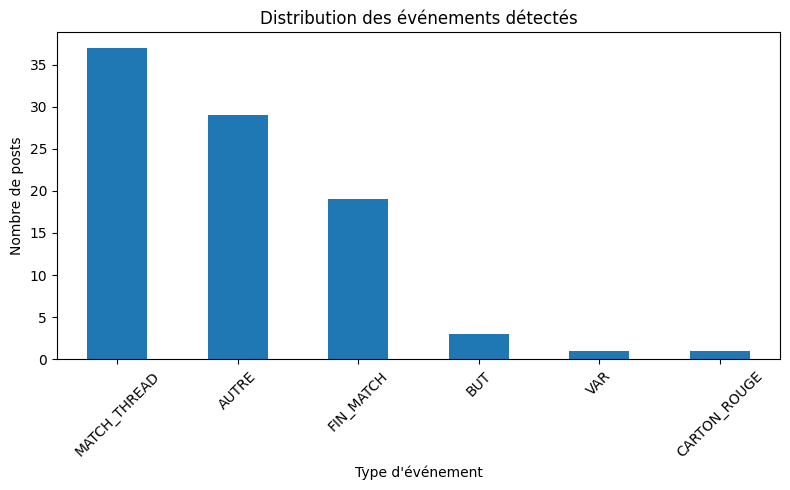

In [46]:
import matplotlib.pyplot as plt

distribution = df_resultats["evenement_v3"].value_counts()

plt.figure(figsize=(8, 5))
distribution.plot(kind="bar")

plt.title("Distribution des événements détectés")
plt.xlabel("Type d'événement")
plt.ylabel("Nombre de posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Partie 37 — Visualisation de la timeline sociale

Après avoir détecté les événements et calculé leur minute relative au match, nous représentons les événements sur une timeline.

Cette visualisation permet d’observer à quel moment les différents types de posts apparaissent autour du match.

In [47]:
df_timeline_v3 = df_resultats[df_resultats["evenement_v3"] != "AUTRE"].copy()

df_timeline_v3 = df_timeline_v3.sort_values(by="minute_match")

df_timeline_v3[["minute_match", "categorie_temps", "evenement_v3", "score", "titre"]].head(30)

,minute_match,categorie_temps,evenement_v3,score,titre
51,-4096762,AVANT_MATCH,FIN_MATCH,3 - 1,[Post Match Thread] Real Madrid 3 - 1 Liverpoo...
33,-3562660,AVANT_MATCH,MATCH_THREAD,NaN,Match Thread: Tottenham vs. Liverpool [UEFA Ch...
17,-3258879,AVANT_MATCH,VAR,NaN,Liverpool Vs Wolves - VAR Rules out Neto's Equ...
12,-3169475,AVANT_MATCH,MATCH_THREAD,3 - 0,Post-Match Thread: Watford 3 - 0 Liverpool [ E...
39,-2207406,AVANT_MATCH,FIN_MATCH,1-0,Post Match Thread: Leicester City 1-0 Liverpoo...
30,-1990160,AVANT_MATCH,MATCH_THREAD,NaN,Match Thread: Liverpool vs Real Madrid | UEFA ...
16,-1989987,AVANT_MATCH,FIN_MATCH,NaN,Post Match Thread: Liverpool 0 vs 1 Real Madri...
24,-1585540,AVANT_MATCH,FIN_MATCH,7 - 0,[Post Match Thread] Liverpool 7 - 0 Manchester...
4,-1585540,AVANT_MATCH,FIN_MATCH,7 - 0,Post Match Thread: Liverpool 7 - 0 Manchester ...
38,-1280104,AVANT_MATCH,FIN_MATCH,2 - 3,Post Match Thread: Manchester United 2 - 3 Gal...


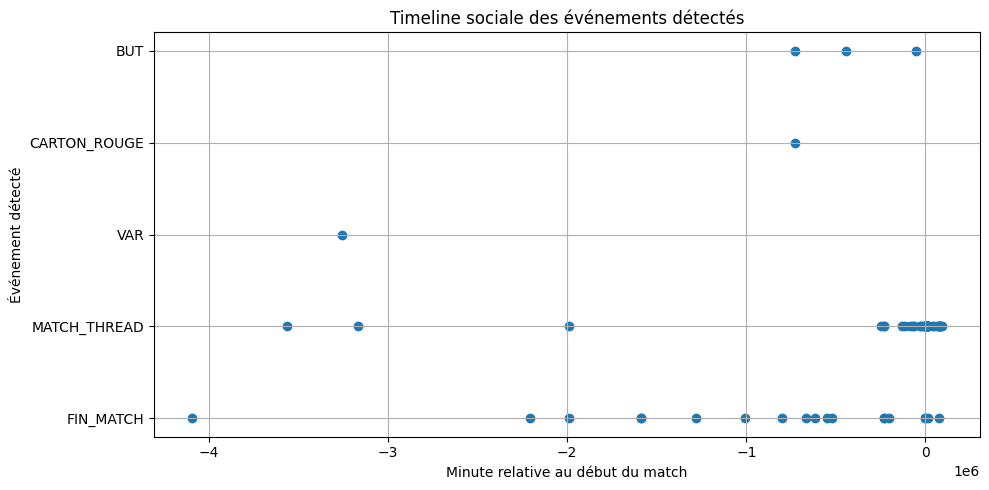

In [48]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_timeline_v3["minute_match"],
    df_timeline_v3["evenement_v3"]
)

plt.title("Timeline sociale des événements détectés")
plt.xlabel("Minute relative au début du match")
plt.ylabel("Événement détecté")
plt.grid(True)
plt.tight_layout()
plt.show()

# Partie 38 — Filtrage temporel de la timeline

La première timeline peut contenir des publications très éloignées du match.

Ces posts mentionnent parfois Liverpool ou Galatasaray, mais ils ne correspondent pas nécessairement à l’événement étudié.

Nous appliquons donc un filtrage temporel afin de conserver uniquement les publications situées dans une fenêtre raisonnable autour du match.

In [49]:
df_timeline_filtre = df_resultats[
    (df_resultats["minute_match"] >= -120) &
    (df_resultats["minute_match"] <= 180) &
    (df_resultats["evenement_v3"] != "AUTRE")
].copy()

df_timeline_filtre[["minute_match", "categorie_temps", "evenement_v3", "score", "titre"]]

,minute_match,categorie_temps,evenement_v3,score,titre
8,-20,AVANT_MATCH,FIN_MATCH,1-0,Post Match Thread: Galatasaray 1-0 Liverpool
58,-21,AVANT_MATCH,FIN_MATCH,1-0,[CHAMPIONS LEAGUE] Post Match Thread: GALATASA...


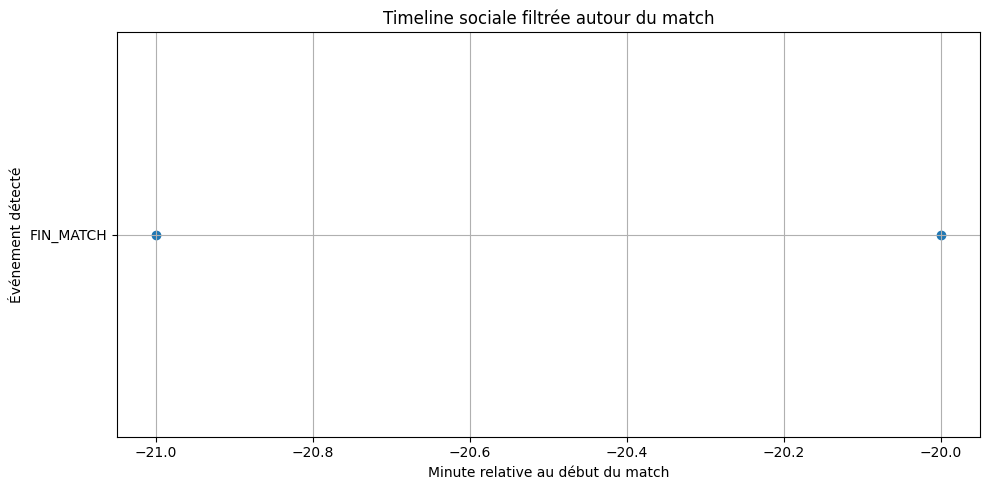

In [50]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_timeline_filtre["minute_match"],
    df_timeline_filtre["evenement_v3"]
)

plt.title("Timeline sociale filtrée autour du match")
plt.xlabel("Minute relative au début du match")
plt.ylabel("Événement détecté")
plt.grid(True)
plt.tight_layout()
plt.show()

# Partie 39 — Distribution des événements dans la timeline filtrée

Après avoir filtré les publications autour du match, nous analysons à nouveau la distribution des événements détectés.

Cette étape permet de vérifier quels types d’événements restent présents dans la fenêtre temporelle pertinente.

In [51]:
distribution_filtre = df_timeline_filtre["evenement_v3"].value_counts()

distribution_filtre

evenement_v3
FIN_MATCH    2
Name: count, dtype: int64

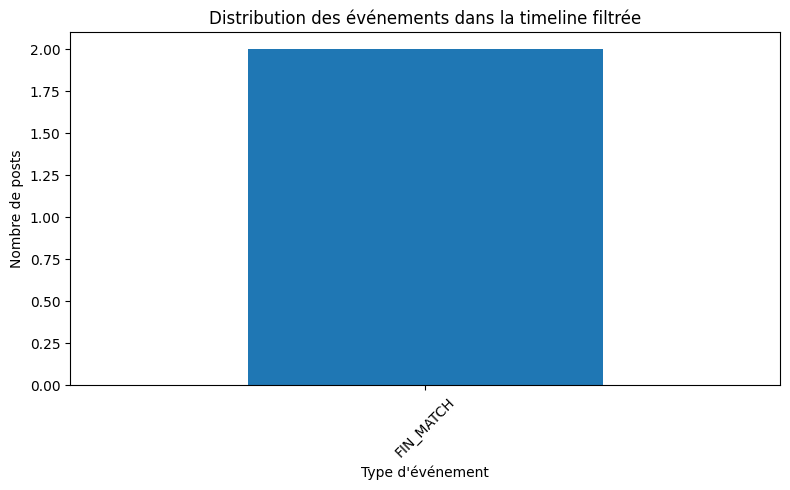

In [52]:
plt.figure(figsize=(8, 5))

distribution_filtre.plot(kind="bar")

plt.title("Distribution des événements dans la timeline filtrée")
plt.xlabel("Type d'événement")
plt.ylabel("Nombre de posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Partie 40 — Visualisation de l’activité sociale

En plus des événements détectés, nous analysons l’intensité de l’activité sociale.

Pour cela, nous utilisons le nombre de commentaires associés aux périodes du match.

L’objectif est d’observer les moments où les discussions sociales sont les plus actives autour de l’événement sportif.

In [53]:
df_activite = df_resultats[
    (df_resultats["minute_match"] >= -120) &
    (df_resultats["minute_match"] <= 180)
].copy()

df_activite[["minute_match", "commentaires_periode", "titre"]].head()

,minute_match,commentaires_periode,titre
8,-20,412,Post Match Thread: Galatasaray 1-0 Liverpool
58,-21,187,[CHAMPIONS LEAGUE] Post Match Thread: GALATASA...
61,-21,99,Galatasaray once again defeats Liverpool at home!
87,44,0,[433] Osimhen não conseguiu segurar as lágrima...
88,-17,0,Liverpool pierde la Galatasaray. Osimhen a fos...


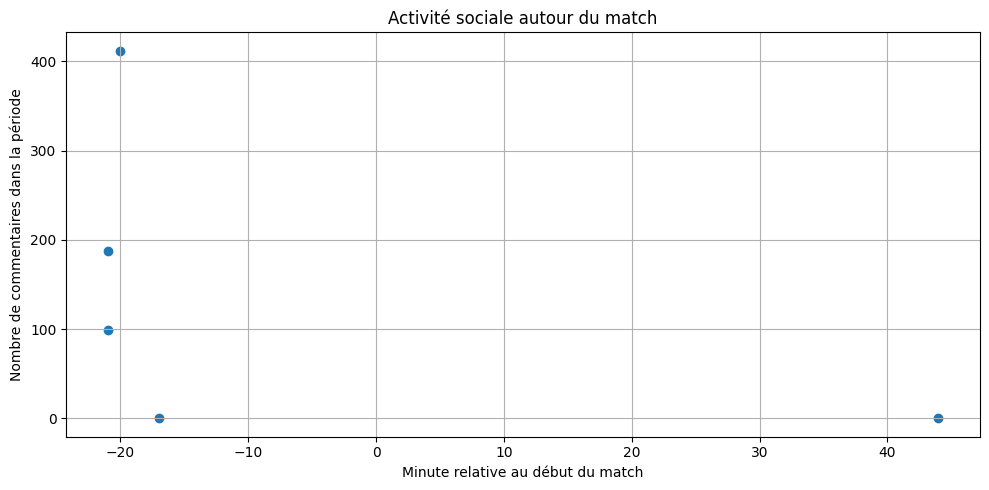

In [55]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_activite["minute_match"],
    df_activite["commentaires_periode"]
)

plt.title("Activité sociale autour du match")
plt.xlabel("Minute relative au début du match")
plt.ylabel("Nombre de commentaires dans la période")
plt.grid(True)
plt.tight_layout()
plt.show()

# Partie 41 — Relation entre événements détectés et activité sociale

Après avoir représenté séparément la timeline et l’activité sociale, nous combinons maintenant les deux informations.

L’objectif est d’observer si certains types d’événements sont associés à un volume plus élevé de commentaires.

Cette étape permet de relier l’analyse TAL à la dynamique sociale du match.

In [56]:
df_evenements_activite = df_resultats[
    (df_resultats["minute_match"] >= -120) &
    (df_resultats["minute_match"] <= 180) &
    (df_resultats["evenement_v3"] != "AUTRE")
].copy()

df_evenements_activite[
    ["minute_match", "evenement_v3", "commentaires_periode", "titre"]
]

,minute_match,evenement_v3,commentaires_periode,titre
8,-20,FIN_MATCH,412,Post Match Thread: Galatasaray 1-0 Liverpool
58,-21,FIN_MATCH,187,[CHAMPIONS LEAGUE] Post Match Thread: GALATASA...


In [57]:
activite_par_evenement = df_evenements_activite.groupby("evenement_v3")["commentaires_periode"].mean()

activite_par_evenement

evenement_v3
FIN_MATCH    299.5
Name: commentaires_periode, dtype: float64

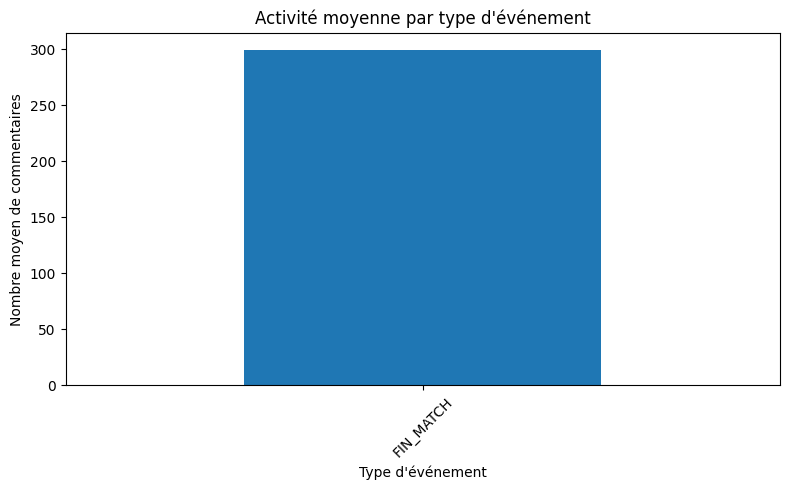

In [58]:
plt.figure(figsize=(8, 5))

activite_par_evenement.plot(kind="bar")

plt.title("Activité moyenne par type d'événement")
plt.xlabel("Type d'événement")
plt.ylabel("Nombre moyen de commentaires")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Partie 42 — Comparaison entre chronologie officielle et chronologie sociale

L’objectif central du projet est de comparer deux types de chronologies :

1. La chronologie officielle du match, composée des événements sportifs réels : début du match, buts, cartons, fin du match.
2. La chronologie sociale, construite à partir des publications et commentaires détectés sur les réseaux sociaux.

Cette comparaison permet d’observer le décalage entre un événement réel et sa manifestation dans les discussions sociales.

In [59]:
chronologie_officielle = pd.DataFrame([
    {"minute_officielle": 0, "evenement_officiel": "DEBUT_MATCH"},
    {"minute_officielle": 90, "evenement_officiel": "FIN_MATCH"}
])

chronologie_officielle

,minute_officielle,evenement_officiel
0,0,DEBUT_MATCH
1,90,FIN_MATCH


In [60]:
df_timeline_filtre[["minute_match", "evenement_v3", "titre"]]

,minute_match,evenement_v3,titre
8,-20,FIN_MATCH,Post Match Thread: Galatasaray 1-0 Liverpool
58,-21,FIN_MATCH,[CHAMPIONS LEAGUE] Post Match Thread: GALATASA...


La chronologie officielle sert de référence.

La chronologie sociale représente les événements détectés automatiquement dans les textes.

La comparaison entre les deux permet d’étudier si les réseaux sociaux réagissent avant, pendant ou après les événements réels.